In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matchms
import pickle

In [2]:
filename = "gnps_positive_ionmode_unique_inchikey_cleaned_by_matchms_and_lookups.json"
reference_spectrums_lookup = matchms.importing.load_from_json(f"src/data/{filename}")

In [3]:
from matchms.filtering import normalize_intensities
from matchms.filtering import require_minimum_number_of_peaks
from matchms.filtering import select_by_mz
from matchms.filtering import select_by_relative_intensity

def post_process(s):
    s = normalize_intensities(s)
    s = select_by_mz(s, mz_from=0, mz_to=1000)
    s = require_minimum_number_of_peaks(s, n_required=10)
    s = select_by_relative_intensity(s, intensity_from=0.01, intensity_to=1.0)
    return s

In [4]:
# apply filters to the data
spectrums = [post_process(s) for s in reference_spectrums_lookup]

# omit spectrums that didn't qualify for analysis
spectrums = [s for s in spectrums if s is not None]

In [5]:
print("Remaining number of spectra:", len(spectrums))

Remaining number of spectra: 4993


In [6]:
from matchms.filtering.add_fingerprint import add_fingerprint

spectrums = [add_fingerprint(s, fingerprint_type="daylight", nbits=2048) for s in spectrums]

In [7]:
for i, spec1 in enumerate(spectrums):
    if spec1.get("fingerprint") is None:
        print(i, "no fingerprint")
    elif spec1.get("fingerprint").sum() < 1:
        print(i, "weird")

In [8]:
from matchms.similarity import FingerprintSimilarity

similarity_measure = FingerprintSimilarity(similarity_measure="jaccard")
scores_mol_similarity = similarity_measure.matrix(spectrums, spectrums)

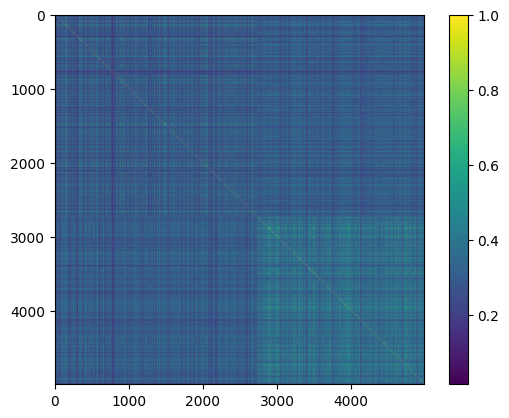

In [9]:
plt.imshow(scores_mol_similarity, cmap="viridis")
plt.colorbar()
plt.show()

In [10]:
n = len(scores_mol_similarity)
row_indices, col_indices = np.triu_indices(n, k=1)

vals = scores_mol_similarity[row_indices, col_indices]
vals

array([1.        , 0.29147287, 0.29147287, ..., 1.        , 0.29602356,
       0.29602356])

In [48]:
print(np.count_nonzero(vals == 1))

3337


In [12]:
mask = np.isclose(vals, 1.0)

In [13]:
i_ones = row_indices[mask]
j_ones = col_indices[mask]

In [14]:
print(i_ones)
print(j_ones)

[   0    2    4 ... 4989 4989 4990]
[   1    3    5 ... 4990 4991 4991]


In [15]:
# implementing gaussian kernel

def gauss_kernel(mz1, mz2, sigma):
  return np.exp(-(mz1 - mz2)**2 / (2 * sigma**2))

def distance(X, Y, sigma):
  d = 0
  n = X.peaks.mz.shape[0]
  m = Y.peaks.mz.shape[0]
  for i in range(n):
    for j in range(m):
      w = X.peaks.intensities[i]
      v = Y.peaks.intensities[j]
      d += w * v * gauss_kernel(X.peaks.mz[i], Y.peaks.mz[j], sigma)
  return d

def normalized_distance(X, Y, sigma=1):
  return distance(X, Y, sigma) / np.sqrt(distance(X, X, sigma) * distance(Y, Y, sigma))

In [50]:
normalized_distance(spectrums[0], spectrums[1], sigma=2)

np.float64(0.9942575775782654)

In [17]:
# too heavy

# gauss_sim_matrix = [normalized_distance(spectrum1, spectrum2, sigma=2) 
#   for spectrum1 in spectrums for spectrum2 in spectrums]

In [51]:
print(len(spectrums), np.mean([len(s.peaks.mz) for s in spectrums]))

4993 76.19887842980172


In [92]:
# Gaussian kernel (vectorized)
def vec_gaussian_kernel(mz_x, mz_y, sigma):
    """
    mz_x: (n,)
    mz_y: (m,)
    returns (n, m) kernel matrix
    """
    diff = mz_x[:, None] - mz_y[None, :]
    return np.exp(-(diff ** 2) / (2 * sigma ** 2))


# Fast unnormalized similarity
def vec_distance(mz_x, inten_x, mz_y, inten_y, sigma):
    K = vec_gaussian_kernel(mz_x, mz_y, sigma)
    return np.sum(K * inten_x[:, None]/2 * inten_y[None, :]/2)

# Normalized similarity
def vec_normalized_distance(mz_x, inten_x, mz_y, inten_y, sigma=2):
    num = vec_distance(mz_x, inten_x, mz_y, inten_y, sigma)
    den = np.sqrt(
        vec_distance(mz_x, inten_x, mz_x, inten_x, sigma) *
        vec_distance(mz_y, inten_y, mz_y, inten_y, sigma)
    )
    return num / den if den > 0 else 0.0

# # Pre-extract spectra
# mz_list = [s.peaks.mz for s in spectrums]
# int_list = [s.peaks.intensities for s in spectrums]

# n = len(spectrums)

# # Compute symmetric similarity matrix 
# gauss_sim_matrix = np.zeros((n, n), dtype=np.float32)

# for i in range(n):
#     # diagonal = 1 by definition
#     gauss_sim_matrix[i, i] = 1.0

#     for j in range(i + 1, n):
#         sim = vec_normalized_distance(
#             mz_list[i], int_list[i],
#             mz_list[j], int_list[j],
#             sigma=2
#         )

#         gauss_sim_matrix[i, j] = sim
#         gauss_sim_matrix[j, i] = sim

In [95]:
import numpy as np

n = len(spectrums)

n_pairs = 10_000

i = np.random.randint(0, n, size=n_pairs)
j = np.random.randint(0, n, size=n_pairs)

# remove self-pairs
mask = i < j
i = i[mask]
j = j[mask]

pairs = list(zip(i, j))

In [96]:
pairs

[(np.int64(1219), np.int64(2685)),
 (np.int64(1386), np.int64(4175)),
 (np.int64(3971), np.int64(4849)),
 (np.int64(4434), np.int64(4704)),
 (np.int64(224), np.int64(1248)),
 (np.int64(224), np.int64(2818)),
 (np.int64(1813), np.int64(4971)),
 (np.int64(560), np.int64(4564)),
 (np.int64(805), np.int64(4308)),
 (np.int64(316), np.int64(1859)),
 (np.int64(2796), np.int64(4979)),
 (np.int64(385), np.int64(4523)),
 (np.int64(3612), np.int64(4904)),
 (np.int64(3533), np.int64(4788)),
 (np.int64(2770), np.int64(3609)),
 (np.int64(1455), np.int64(3527)),
 (np.int64(2540), np.int64(2766)),
 (np.int64(3095), np.int64(3265)),
 (np.int64(2044), np.int64(4682)),
 (np.int64(133), np.int64(4285)),
 (np.int64(182), np.int64(4958)),
 (np.int64(1747), np.int64(4347)),
 (np.int64(2424), np.int64(4653)),
 (np.int64(750), np.int64(3274)),
 (np.int64(2943), np.int64(4470)),
 (np.int64(3369), np.int64(4592)),
 (np.int64(2439), np.int64(2848)),
 (np.int64(2163), np.int64(3935)),
 (np.int64(1458), np.int64(16

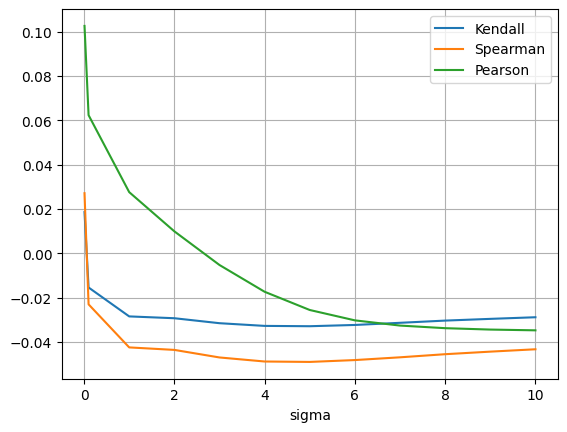

In [97]:
from scipy.stats import spearmanr, pearsonr, kendalltau

kendalls = []
spearmans = []
pearsons = []
sigmas = [0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for sigma in sigmas:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma))
  spearmans.append(spearmanr(random_pairs_jaccard, random_pairs_gaussian)[0])
  pearsons.append(pearsonr(random_pairs_jaccard, random_pairs_gaussian)[0])
  kendalls.append(kendalltau(random_pairs_jaccard, random_pairs_gaussian)[0])

plt.plot(sigmas, kendalls, label="Kendall")
plt.plot(sigmas, spearmans, label="Spearman")
plt.plot(sigmas, pearsons, label="Pearson")
plt.legend()
plt.grid()
plt.xlabel("sigma")
plt.show()

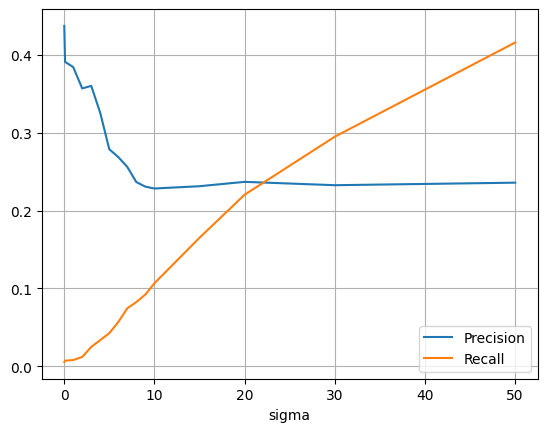

In [100]:
from sklearn.metrics import precision_score, recall_score


precisions = []
recalls = []
sigmas = [0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50]
for sigma in sigmas:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma))
  y_true = np.array(random_pairs_jaccard)
  y_pred = np.array(random_pairs_gaussian)

  threshold_true = 0.4
  threshold_pred = 0.7

  y_true_bin = (y_true >= threshold_true).astype(int)
  y_pred_bin = (y_pred >= threshold_pred).astype(int)
  precisions.append(precision_score(y_true_bin, y_pred_bin))
  recalls.append(recall_score(y_true_bin, y_pred_bin))

plt.plot(sigmas, precisions, label="Precision")
plt.plot(sigmas, recalls, label="Recall")
plt.legend()
plt.grid()
plt.xlabel("sigma")
plt.show()

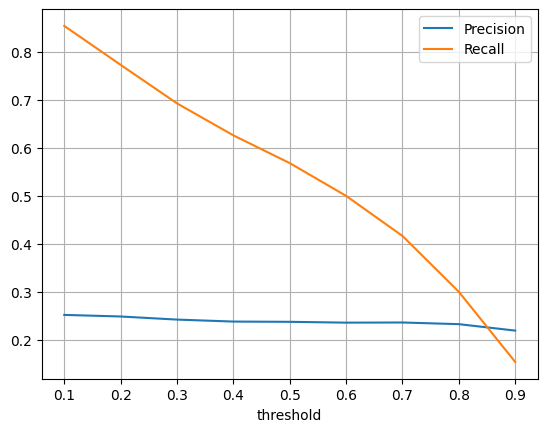

In [101]:
from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []
sigma = 50
seps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for sep in seps:
  random_pairs_jaccard = []
  random_pairs_gaussian = []
  for pair in pairs:
    random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
    random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                        spectrums[pair[0]].peaks.intensities,
                                                        spectrums[pair[1]].peaks.mz,
                                                        spectrums[pair[1]].peaks.intensities, sigma))
  y_true = np.array(random_pairs_jaccard)
  y_pred = np.array(random_pairs_gaussian)

  threshold_true = 0.4
  threshold_pred = sep
  y_true_bin = (y_true >= threshold_true).astype(int)
  y_pred_bin = (y_pred >= threshold_pred).astype(int)
  precisions.append(precision_score(y_true_bin, y_pred_bin))
  recalls.append(recall_score(y_true_bin, y_pred_bin))

plt.plot(seps, precisions, label="Precision")
plt.plot(seps, recalls, label="Recall")
plt.legend()
plt.grid()
plt.xlabel("threshold")
plt.show()

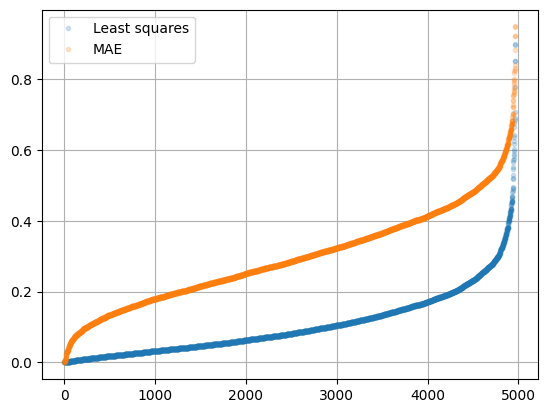

In [116]:
sigma = 0.01

random_pairs_jaccard = []
random_pairs_gaussian = []
for pair in pairs:
  random_pairs_jaccard.append(scores_mol_similarity[pair[0], pair[1]])
  random_pairs_gaussian.append(vec_normalized_distance(spectrums[pair[0]].peaks.mz,
                                                      spectrums[pair[0]].peaks.intensities,
                                                      spectrums[pair[1]].peaks.mz,
                                                      spectrums[pair[1]].peaks.intensities, sigma))
y_true = np.array(random_pairs_jaccard)
y_pred = np.array(random_pairs_gaussian)

# least squares on ytrue and ypred

lsq = (y_true - y_pred)**2
plt.plot(sorted(lsq), '.', alpha=0.2, label='Least squares')
plt.legend()

mae = np.abs(y_true - y_pred)
plt.plot(sorted(mae), '.', alpha=0.2, label='MAE')
plt.legend()

plt.grid()
plt.show()